In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [ ]:
#Load data
df = pd.read_excel("../Pupilometri/Left_manually_cleaned_artefacts.xlsx", sheet_name=0,skiprows=8)
df = df.dropna(axis=1)
df = df.drop('Time', axis=1) # normally 30hz 

df_mean = df.mean()


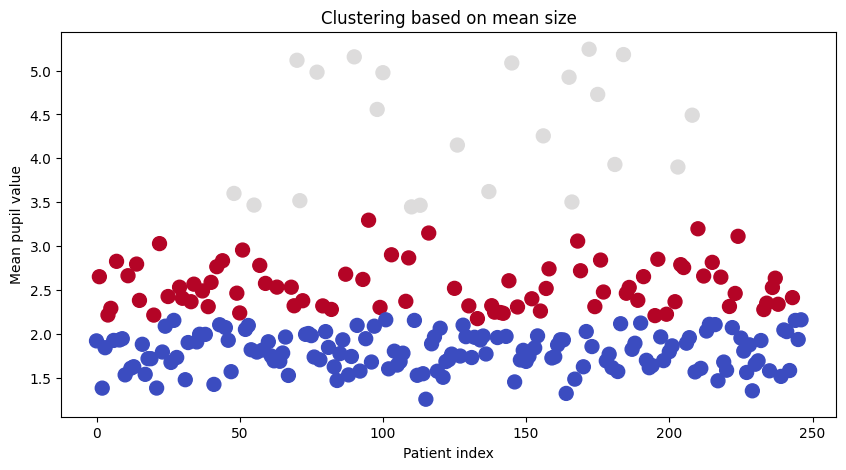

In [4]:
X_mean = df_mean.values.reshape(-1, 1)

# Try to standadize the data
# scaler = StandardScaler()
# X_mean = scaler.fit_transform(X_mean)

kmeans_mean = KMeans(n_clusters=3, random_state=42)
clusters_mean = kmeans_mean.fit_predict(X_mean)


plt.figure(figsize=(10,5))
plt.scatter(range(len(clusters_mean)), X_mean[:,0], c=clusters_mean, cmap='coolwarm', s=100)
plt.xlabel("Patient index")
plt.ylabel("Mean pupil value")
plt.title("Clustering based on mean size")

plt.show()

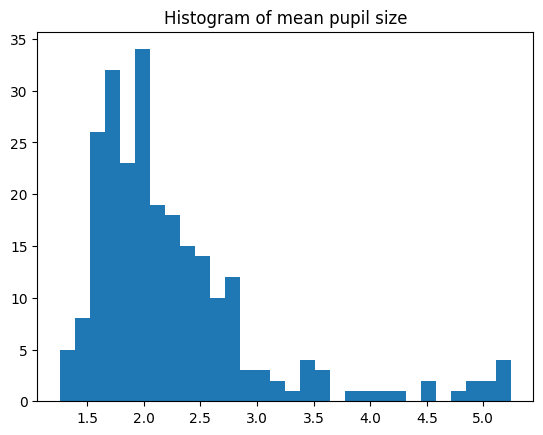

In [5]:
plt.hist(df_mean, bins=30)
plt.title("Histogram of mean pupil size")
plt.show()

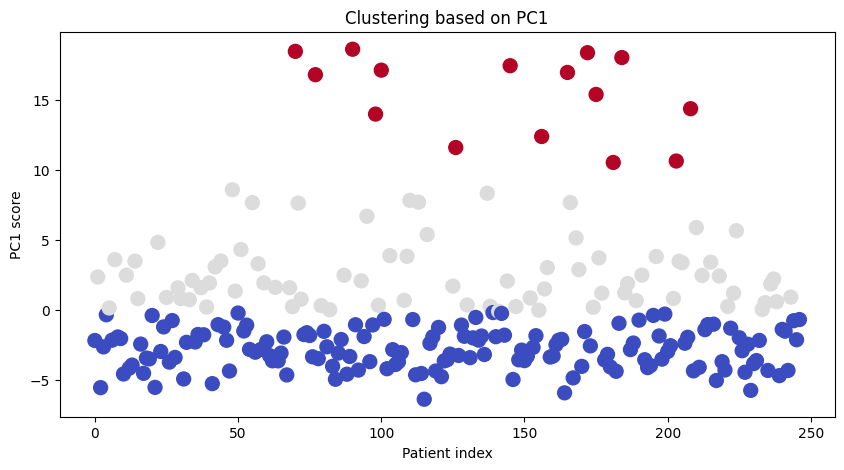

In [ ]:
df = pd.read_excel("../Pupilometri/Left_manually_cleaned_artefacts.xlsx", sheet_name=0,skiprows=8)
df = df.dropna(axis=1)
df = df.drop('Time', axis=1) # normally 30hz 
df_skip = df.iloc[::10] # 3 hz

# Apply PCA
pca = PCA(n_components=10)
principal_components = pca.fit_transform(df_skip.T)


# Cluster only on PC1
from sklearn.cluster import KMeans
X = principal_components 
kmeans_pc1 = KMeans(n_clusters=3, random_state=42)
clusters_pc1 = kmeans_pc1.fit_predict(X[:,0].reshape(-1,1))

plt.figure(figsize=(10,5))
plt.scatter(range(len(clusters_pc1)), X[:,0], c=clusters_pc1, cmap='coolwarm', s=100)
plt.xlabel("Patient index")
plt.ylabel("PC1 score")
plt.title("Clustering based on PC1")
plt.show()

In [7]:
from sklearn.metrics import adjusted_rand_score

score = adjusted_rand_score(clusters_pc1, clusters_mean)
print("Cluster agreement:", score)

Cluster agreement: 0.8458274501836897
